# Freesound SVM Classification

This notebook shows how to build an **audio classifier** using a Support Vector Machine (SVM) trained on sounds downloaded directly from [Freesound](https://freesound.org) — a collaborative database of Creative Commons audio samples.

## What we will do

The classifier learns to distinguish between sound classes from short audio descriptors (numerical features extracted from each sound). Once trained, we give it a completely new sound that it has never seen, and observe which training class it assigns to it.

## What is a Support Vector Machine?

An SVM is a **supervised machine learning classifier**. It finds the hyperplane in feature space that best separates the classes by maximising the margin between the nearest training examples (the *support vectors*) of each class. When classes are not linearly separable, the **RBF (Radial Basis Function) kernel** projects the data into a higher-dimensional space where a linear separator can be found.

## Notebook structure

| Stage | Description |
|-------|-------------|
| **1** | Set up imports, select audio descriptors, and download sounds from Freesound |
| **2** | Download a separate *query* sound — an out-of-distribution test |
| **3** | Extract features, split into train/test, train and evaluate the SVM |
| **4** | Project to 2D with PCA and explore the result interactively |


In [5]:
import json
import pickle
import platform
import shutil
import subprocess
from pathlib import Path

import freesound as fs
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

# Descriptor names adapted to the current Freesound analysis payload schema
# (no lowlevel/sfx prefix keys in API responses).
descriptors = [
    'spectral_centroid',
    'dissonance',
    'spectral_rolloff',
    'log_attack_time',
    'inharmonicity',
    'tristimulus',
    'mfcc',
]

# Mapping of flattened descriptor dimensions (for downstream feature-vector use)
descriptorMapping = {
    0: 'spectral_centroid',
    1: 'dissonance',
    2: 'spectral_rolloff',
    3: 'log_attack_time',
    4: 'inharmonicity',
    5: 'tristimulus.0',
    6: 'tristimulus.1',
    7: 'tristimulus.2',
    8: 'mfcc.0',
    9: 'mfcc.1',
    10: 'mfcc.2',
    11: 'mfcc.3',
    12: 'mfcc.4',
    13: 'mfcc.5',
}

## Stage 1: Audio Descriptors

Instead of working with raw audio waveforms, we represent each sound as a compact **feature vector** — a list of numbers that capture different perceptual properties of the sound. These are called *audio descriptors*.

### Selected descriptors

| Index | Descriptor | What it measures |
|-------|-----------|-----------------|
| 0 | `spectral_centroid` | Brightness — the "centre of mass" of the spectrum (higher = brighter) |
| 1 | `dissonance` | How harsh or rough the sound is (beating between partials) |
| 2 | `spectral_rolloff` | Frequency below which 85% of spectral energy is concentrated |
| 3 | `log_attack_time` | How quickly the sound reaches its peak amplitude (log scale) |
| 4 | `inharmonicity` | Deviation of partials from a perfect harmonic series |
| 5–7 | `tristimulus[0–2]` | Balance of energy across low, mid, and high harmonics (3 values) |
| 8–13 | `mfcc[0–5]` | Mel-frequency cepstral coefficients — a compact timbral fingerprint (6 values) |

`tristimulus` and `mfcc` are **vector-valued**, so they contribute multiple dimensions to the final feature vector, giving us **14 dimensions** in total.

The `descriptorMapping` dictionary maps each dimension index (0–13) to its human-readable name, which is used for axis labels and debugging.

> **Why these descriptors?** Together they describe the *timbre* of an instrument: brightness, attack, harmonic structure, and spectral envelope — properties that differ substantially between violin, bassoon, guitar, and flute.


In [6]:
def download_sounds_freesound(queryText = "", tag=None, duration=None, API_Key = "", outputDir = "", topNResults = 5, featureExt = '.json'):
  """
  This function downloads sounds and their descriptors from freesound using the queryText and the
  tag specified in the input. Additionally, you can also specify the duration range to filter sounds
  based on duration.

  Inputs:
        (Input parameters marked with a * are optional)
        queryText (string): query text for the sounds (eg. "violin", "trumpet", "cello", "bassoon" etc.)
        tag* (string): tag to be used for filtering the searched sounds. (eg. "multisample",
                       "single-note" etc.)
        duration* (tuple): min and the max duration (seconds) of the sound to filter, eg. (0.2,15)
        API_Key (string): your api key, which you can obtain from : www.freesound.org/apiv2/apply/
        outputDir (string): path to the directory where you want to store sounds and descriptors
        topNResults (integer): maximum number of candidates to check/store
        featureExt (string): file extension for storing sound descriptors
  output:
        Stores downloaded previews and descriptors in outputDir/queryText and returns the number
        of successfully saved sounds.
  """
  import requests

  def _to_dict(obj):
    if obj is None:
      return None
    if isinstance(obj, dict):
      return obj
    if hasattr(obj, 'as_dict'):
      try:
        return obj.as_dict()
      except Exception:
        return None
    return None

  def _get_nested_value(obj, path):
    dct = _to_dict(obj)
    if isinstance(dct, dict):
      if path in dct:
        return dct[path]
      cur = dct
      for key in path.split('.'):
        if isinstance(cur, dict) and key in cur:
          cur = cur[key]
        else:
          cur = None
          break
      if cur is not None:
        return cur

    cur = obj
    for key in path.split('.'):
      if cur is None:
        return None
      cur = getattr(cur, key, None)
    return cur

  def _extract_descriptor_value(analysis_obj, desc):
    # 1) Try exact path first.
    val = _get_nested_value(analysis_obj, desc)
    if val is not None:
      if isinstance(val, dict) and 'mean' in val:
        return val['mean']
      return val

    # 2) Freesound may return descriptors without '.mean'.
    if desc.endswith('.mean'):
      base_desc = desc[:-5]
      val = _get_nested_value(analysis_obj, base_desc)
      if val is not None:
        if isinstance(val, dict) and 'mean' in val:
          return val['mean']
        return val

    return None

  def _fetch_analysis_http(sound_id):
    url = f"https://freesound.org/apiv2/sounds/{sound_id}/analysis/"
    headers = {"Authorization": f"Token {API_Key}"}
    params = {
      "descriptors": ','.join(descriptors),
      "normalized": 1,
    }
    resp = requests.get(url, headers=headers, params=params, timeout=12)
    resp.raise_for_status()
    return resp.json()

  # Validate input parameters
  if queryText == "":
    print("\nProvide a query text to search for sounds")
    return -1

  if API_Key == "":
    print("\nYou need a valid freesound API key to download sounds.")
    print("Please apply for one here: www.freesound.org/apiv2/apply/\n")
    return -1

  max_candidates = int(topNResults)
  if max_candidates <= 0:
    print("topNResults must be > 0")
    return 0

  if outputDir == "":
    print("\nPlease provide an output directory path")
    return -1

  output_root = Path(outputDir)
  output_root.mkdir(parents=True, exist_ok=True)

  # Prepare query-specific directory up front so it always exists
  outDir2 = output_root / queryText
  if outDir2.exists():
    shutil.rmtree(outDir2)
  outDir2.mkdir(parents=True, exist_ok=True)
  print("Output directory:", str(outDir2))

  # Setup Freesound client
  fsClnt = fs.FreesoundClient()
  fsClnt.set_token(API_Key, "token")

  # Build filters
  if duration and isinstance(duration, tuple):
    flt_dur = " duration:[" + str(duration[0]) + " TO " + str(duration[1]) + "]"
  else:
    flt_dur = ""

  if tag and isinstance(tag, str):
    flt_tag = "tag:" + tag
  else:
    flt_tag = ""

  # Query Freesound and request analysis descriptors in search results.
  page_size = 30
  fields = "id,name,previews,username,url,analysis"
  try:
    if not flt_tag + flt_dur == "":
      qRes = fsClnt.search(
        query=queryText,
        filter=flt_tag + flt_dur,
        sort="score",
        fields=fields,
        descriptors=','.join(descriptors),
        page_size=page_size,
        normalized=1,
      )
    else:
      qRes = fsClnt.search(
        query=queryText,
        sort="score",
        fields=fields,
        descriptors=','.join(descriptors),
        page_size=page_size,
        normalized=1,
      )
  except Exception as exc:
    print("Search failed:", str(exc))
    return 0

  available = int(getattr(qRes, 'count', 0))
  max_attempts = min(max_candidates, available, 200)
  if max_attempts <= 0:
    print("No search results found for this query/filter combination.")
    return 0

  downloadedSounds = []
  sndCnt = 0
  indCnt = 0
  pageNo = 1
  warned_missing_descriptors = set()

  while indCnt < max_attempts:
    try:
      sound = qRes[indCnt - ((pageNo - 1) * page_size)]
    except Exception as exc:
      print("Failed to read result item:", str(exc))
      break

    print("Processing candidate %d/%d, saved %d, id: %s" % (indCnt + 1, max_attempts, sndCnt, str(sound.id)))

    outDir1 = outDir2 / str(sound.id)
    if outDir1.exists():
      shutil.rmtree(outDir1)
    outDir1.mkdir(parents=True, exist_ok=True)

    preview_lq = sound.previews.preview_lq_mp3 if hasattr(sound.previews, 'preview_lq_mp3') else None
    preview_hq = sound.previews.preview_hq_mp3 if hasattr(sound.previews, 'preview_hq_mp3') else None
    preview_url = preview_lq or preview_hq

    if not preview_url:
      print("  Skipping id %s: no preview URL available" % str(sound.id))
      shutil.rmtree(outDir1)
      indCnt += 1
      if indCnt % page_size == 0 and indCnt < max_attempts:
        qRes = qRes.next_page()
        pageNo += 1
      continue

    mp3_filename = str(preview_url.split("/")[-1])
    mp3Path = outDir1 / mp3_filename
    ftrPath = Path(str(mp3Path).replace('.mp3', featureExt))

    try:
      fs.FSRequest.retrieve(preview_url, fsClnt, str(mp3Path))

      # Use search payload analysis if present; otherwise fetch analysis via direct HTTP API.
      analysis_obj = getattr(sound, 'analysis', None)
      if analysis_obj is None:
        analysis_obj = _fetch_analysis_http(sound.id)

      features = {}
      for desc in descriptors:
        val = _extract_descriptor_value(analysis_obj, desc)
        if val is None:
          # Keep the sound and fill missing descriptor with 0.0 for robustness.
          val = 0.0
          if desc not in warned_missing_descriptors:
            print("  Warning: missing descriptor '%s' in some sounds. Filling with 0.0" % desc)
            warned_missing_descriptors.add(desc)
        features[desc] = [val]

      with open(ftrPath, 'w') as f:
        json.dump(features, f)
      downloadedSounds.append([str(sound.id), sound.url])
      sndCnt += 1

    except Exception as exc:
      print("  Failed id %s: %s" % (str(sound.id), str(exc)))
      if outDir1.exists():
        shutil.rmtree(outDir1)

    indCnt += 1

    if indCnt % page_size == 0 and indCnt < max_attempts:
      qRes = qRes.next_page()
      pageNo += 1

  # Dump list of saved files and Freesound links
  sound_list_path = outDir2 / (queryText + '_SoundList.txt')
  with open(sound_list_path, 'w') as fid:
    for elem in downloadedSounds:
      fid.write('\t'.join(elem) + '\n')

  print("Checked %d candidates and saved %d sounds in %s" % (max_attempts, sndCnt, str(outDir2)))

  return sndCnt

### Downloading training data from Freesound

`download_sounds_freesound()` does three things for each sound it finds:

1. **Searches** Freesound using the query text, optional tag, and duration filter.
2. **Downloads** the low-quality MP3 preview so we can play the sound later.
3. **Fetches analysis descriptors** — the numerical features — and saves them as a `.json` file alongside the audio.

Each sound is stored in its own sub-folder:
```
descSounds/
  violin/          ← class folder (= label)
    355883/        ← sound ID folder
      355883.mp3
      355883.json  ← descriptor values
    355884/
      ...
  bassoon/
    ...
  guitar/
    ...
```

We download **20 sounds per class**, filtered to `tag=single-note` and `duration=(0, 5)` seconds. Single-note samples are ideal because they isolate the instrument's timbre from melodic or rhythmic variation.

> The cell below is wrapped in `'''...'''` to prevent accidental re-downloading. Remove the triple-quotes to fetch fresh data.


In [7]:
# call download_sounds_freesound() for the sounds chosen
Path('descSounds').mkdir(parents=True, exist_ok=True)
myKey="UAdYw5edzBy46O6GxQKLQKfpw5Sjl66ZFLakG4PD"   # <-- insert your Freesound API key here

download_sounds_freesound(queryText='cello',API_Key=myKey,outputDir='descSounds/', topNResults=10,duration=(0,3), tag='single-note')
download_sounds_freesound(queryText='violin',API_Key=myKey,outputDir='descSounds/', topNResults=20,duration=(0,5), tag='single-note')
download_sounds_freesound(queryText='bassoon',API_Key=myKey,outputDir='descSounds/', topNResults=20,duration=(0,5), tag='single-note')
download_sounds_freesound(queryText='guitar',API_Key=myKey,outputDir='descSounds/', topNResults=20,duration=(0,5), tag='single-note')

Output directory: descSounds\cello
Processing candidate 1/10, saved 0, id: 358277
Processing candidate 2/10, saved 1, id: 358276
Processing candidate 3/10, saved 2, id: 358274
Processing candidate 4/10, saved 3, id: 358273
Processing candidate 5/10, saved 4, id: 358268
Processing candidate 6/10, saved 5, id: 358267
Processing candidate 7/10, saved 6, id: 358266
Processing candidate 8/10, saved 7, id: 358263
Processing candidate 9/10, saved 8, id: 358242
Processing candidate 10/10, saved 9, id: 358240
Checked 10 candidates and saved 10 sounds in descSounds\cello
Output directory: descSounds\violin
Processing candidate 1/20, saved 0, id: 356182
Processing candidate 2/20, saved 1, id: 356178
Processing candidate 3/20, saved 2, id: 356177
Processing candidate 4/20, saved 3, id: 356176
Processing candidate 5/20, saved 4, id: 356175
Processing candidate 6/20, saved 5, id: 356174
Processing candidate 7/20, saved 6, id: 356173
Processing candidate 8/20, saved 7, id: 356172
Processing candidate

20

## Stage 2: Download Query Sound

The query sound is a **flute** recording — a class the SVM has **never seen during training**.

This simulates a realistic use case: you train on some instruments and then present the model with an unknown one to see which training class it considers most similar.

- Saved to `svm_query_sound/flute/`
- **Not** included in the training or test split
- Prediction is therefore always a "closest match" from {violin, bassoon, guitar, cello}

In [8]:
# ── Stage 2: Download query sound (flute) ──────────────────────────────────
# A single flute sound is downloaded as the query.
# Flute is intentionally NOT in the training set — the SVM must assign it to
# whichever training class it resembles most (violin, bassoon, guitar, or cello).
# The sound is saved to svm_query_sound/flute/ and is never used in training.

Path('svm_query_sound').mkdir(parents=True, exist_ok=True)

n_query = download_sounds_freesound(
    queryText='flute',
    API_Key=myKey,
    outputDir='svm_query_sound/',
    topNResults=1,
    duration=(0, 5),
    tag='single-note',
)

if n_query < 1:
    raise RuntimeError(
        'Query sound download failed — check API key and network connection.'
    )

print(f'✓ Query sound ready in: svm_query_sound/flute/')

Output directory: svm_query_sound\flute
Processing candidate 1/1, saved 0, id: 373360
Checked 1 candidates and saved 1 sounds in svm_query_sound\flute
✓ Query sound ready in: svm_query_sound/flute/


## Stage 3: Data Preparation and SVM Model Training

This stage covers the full machine learning pipeline:

1. **Feature extraction** — Load the descriptor JSON files, convert each one to a fixed-length numpy vector.
2. **Train/test split** — Hold out 20% of the data for evaluation; never train on it.
3. **Standardisation** — Rescale every feature dimension to zero mean and unit variance.
4. **SVM training** — Fit a kernel SVM on the scaled training vectors.
5. **Evaluation** — Measure accuracy, precision, recall, F1, and inspect the confusion matrix.
6. **Query prediction** — Run the flute sound (unseen class) through the trained model.


In [9]:
# Helper functions for feature extraction and data preparation

def convFtrDict2List(ftrDict):
    """Convert feature dictionary to feature vector using descriptorMapping."""
    ftr = []
    for key in range(len(descriptorMapping.keys())):
        desc_name = descriptorMapping[key]
        try:
            # Handle vector descriptors (tristimulus, mfcc)
            if '.' in desc_name and desc_name.split('.')[-1].isdigit():
                idx = int(desc_name.split('.')[-1])
                base_name = '.'.join(desc_name.split('.')[:-1])
                if base_name in ftrDict:
                    val = ftrDict[base_name][0]
                    if isinstance(val, (list, np.ndarray)):
                        ftr.append(float(val[idx]))
                    else:
                        ftr.append(float(val))
                else:
                    ftr.append(0.0)
            else:
                if desc_name in ftrDict:
                    val = ftrDict[desc_name][0]
                    if isinstance(val, (list, np.ndarray)) and len(val) > 0:
                        ftr.append(float(val[0]))
                    else:
                        ftr.append(float(val))
                else:
                    ftr.append(0.0)
        except Exception:
            ftr.append(0.0)
    return np.array(ftr, dtype=float)

def fetchDataDetails(inputDir, descExt='.json'):
    """Recursively load all descriptor JSON files from input directory."""
    dataDetails = {}
    for path in Path(inputDir).rglob(f'*{descExt}'):
        sound_dir = path.parent
        class_dir = sound_dir.parent
        cname = class_dir.name
        sname = sound_dir.name
        if cname not in dataDetails:
            dataDetails[cname] = {}
        try:
            with open(path, 'r', encoding='utf-8') as file_obj:
                fDict = json.load(file_obj)
            dataDetails[cname][sname] = {'file': path.name, 'feature': fDict}
        except Exception as e:
            print(f"Warning: Failed to load {path}: {e}")
    return dataDetails

def build_svm_dataset(input_dir: str, selected_descriptors: list):
    """Build feature matrix, labels, and sound IDs from training data."""
    data_details = fetchDataDetails(input_dir)
    features = []
    labels = []
    sound_ids = []

    for class_name in sorted(data_details.keys()):
        for sound_name in sorted(data_details[class_name].keys()):
            full_vector = convFtrDict2List(data_details[class_name][sound_name]['feature'])
            features.append(full_vector[:len(selected_descriptors)])
            labels.append(class_name)
            sound_ids.append(sound_name)

    return np.array(features, dtype=float), np.array(labels), sound_ids

def _standardize_train_query(train_data: np.ndarray, query_data: np.ndarray = None):
    """Standardize training data and optionally query data using training statistics."""
    mean = np.mean(train_data, axis=0, keepdims=True)
    std = np.std(train_data, axis=0, keepdims=True)
    std[std == 0] = 1.0
    scaled_train = (train_data - mean) / std
    if query_data is None:
        return scaled_train, mean, std
    scaled_query = (query_data - mean.ravel()) / std.ravel()
    return scaled_train, scaled_query, mean, std

### From JSON descriptors to feature vectors

Each sound's descriptor file contains a dictionary like:
```json
{
  "spectral_centroid": [0.42],
  "mfcc": [[0.1, -0.3, 0.7, 0.2, -0.1, 0.5]],
  ...
}
```

`convFtrDict2List()` converts this into a flat 14-dimensional numpy array by reading values in the fixed order defined by `descriptorMapping`. Vector-valued descriptors (`tristimulus`, `mfcc`) are unpacked element-by-element:

$$\mathbf{x} = [\underbrace{s_c, d, s_r, lat, inh}_{\text{5 scalars}},\ \underbrace{t_0, t_1, t_2}_{\text{tristimulus}},\ \underbrace{m_0, m_1, m_2, m_3, m_4, m_5}_{\text{MFCC}}]$$

`fetchDataDetails()` walks the `descSounds/` folder tree and returns a nested dictionary keyed by `class → sound_id → features`. `build_svm_dataset()` then assembles the full feature matrix **X** and label vector **y** by iterating over all classes and sounds.

### Standardisation (Z-score normalisation)

Before training, each feature dimension $j$ is rescaled so that it has **zero mean and unit variance** across the training set:

$$x'_j = \frac{x_j - \mu_j}{\sigma_j}$$

This is critical for SVMs because the RBF kernel computes Euclidean distances between points — unscaled features with large numerical ranges (e.g. spectral centroid vs. log attack time) would dominate the distance and bias the classifier. The mean $\mu$ and standard deviation $\sigma$ are computed **only on the training set** and then applied to the test set and query sound to avoid data leakage.


In [10]:
# Load training data and prepare feature matrix

training_dir = Path('descSounds')
selected_descriptors = descriptors  # Use the descriptors defined in cell 2

print("Loading training data from:", training_dir)
full_features, full_labels, sound_ids = build_svm_dataset(str(training_dir), selected_descriptors)

print(f"\nDataset Summary:")
print(f"  Total samples: {len(full_features)}")
print(f"  Classes: {sorted(set(full_labels))}")
print(f"  Feature vector size: {full_features.shape[1]}")

# Split data into training and test sets (stratified, 80/20 split)
X_train, X_test, y_train, y_test, train_ids, test_ids = train_test_split(
    full_features, full_labels, sound_ids, test_size=0.2, random_state=42, stratify=full_labels
)

print(f"\nTrain/Test Split:")
print(f"  Training set: {len(X_train)} samples")
print(f"  Test set: {len(X_test)} samples")

# Standardize features using training set statistics
X_train_scaled, X_test_scaled, train_mean, train_std = _standardize_train_query(X_train, X_test)

print(f"\nFeature Standardization:")
print(f"  Training mean: {train_mean}")
print(f"  Training std: {train_std}")

Loading training data from: descSounds

Dataset Summary:
  Total samples: 70
  Classes: [np.str_('bassoon'), np.str_('cello'), np.str_('guitar'), np.str_('violin')]
  Feature vector size: 7

Train/Test Split:
  Training set: 56 samples
  Test set: 14 samples

Feature Standardization:
  Training mean: [[1.34748875e+03 3.19017857e-01 1.98338323e+03 0.00000000e+00
  3.25535714e-02 2.93553571e-01 4.62267857e-01]]
  Training std: [[1.41322219e+03 8.91712820e-02 2.10325670e+03 1.00000000e+00
  1.68267640e-02 1.29431024e-01 1.36732336e-01]]


### Train/test split

We split the dataset into a **training set (80%)** and a **test set (20%)** using `train_test_split()`.

Key choices:
- **`stratify=full_labels`** — ensures that each class is represented proportionally in both splits. Without stratification, a random split could accidentally put all samples of a small class into the training set, making evaluation on that class impossible.
- **`random_state=42`** — fixes the random seed so results are reproducible.
- The test set is set aside and **never used during training**. We only look at it when evaluating the trained model.

> Rule of thumb: the model sees training data during `.fit()`, and the test set is the held-out "exam" that estimates real-world performance.


In [11]:
# Train SVM classifier
print("Training SVM classifier (RBF kernel)...")
svm_model = SVC(kernel='rbf', C=10.0, gamma='scale', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

print("✓ SVM model training completed!")
print(f"  Number of support vectors: {len(svm_model.support_vectors_)}")
print(f"  Number of support vectors per class: {svm_model.n_support_}")

Training SVM classifier (RBF kernel)...
✓ SVM model training completed!
  Number of support vectors: 42
  Number of support vectors per class: [ 9  8 11 14]


### How the SVM works

An SVM finds the **maximum-margin hyperplane** that separates classes in feature space. The *margin* is the distance between the hyperplane and the nearest training points of each class — those nearest points are the **support vectors**.

#### RBF kernel

Because instrument classes are not linearly separable in 14-dimensional feature space, we use the **Radial Basis Function (RBF) kernel**:

$$K(\mathbf{x}_i, \mathbf{x}_j) = \exp\!\left(-\gamma \|\mathbf{x}_i - \mathbf{x}_j\|^2\right)$$

This implicitly maps data to a higher-dimensional space where a linear separator exists, without ever computing the mapping explicitly.

#### Hyperparameters

| Parameter | Value | Effect |
|-----------|-------|--------|
| `C=10.0` | Regularisation strength | Large C → tighter fit, smaller margin (less tolerance for misclassified points) |
| `gamma='scale'` | RBF bandwidth | `'scale'` sets $\gamma = 1 / (n\_features \times \text{Var}(\mathbf{X}))$ — adapts to the data automatically |
| `probability=True` | Calibrated probabilities | Enables `.predict_proba()` so we can see confidence scores per class |

With three classes (violin, bassoon, guitar) the SVM trains **one-vs-one** binary classifiers for each pair and combines their votes to produce the final prediction.


MODEL EVALUATION (Test Set)

Overall Performance:
  Accuracy:  0.7143
  Precision: 0.7762
  Recall:    0.7143
  F1-Score:  0.7159

Per-Class Metrics:
              precision    recall  f1-score   support

     bassoon     0.8000    1.0000    0.8889         4
       cello     0.3333    0.5000    0.4000         2
      guitar     1.0000    0.5000    0.6667         4
      violin     0.7500    0.7500    0.7500         4

    accuracy                         0.7143        14
   macro avg     0.7208    0.6875    0.6764        14
weighted avg     0.7762    0.7143    0.7159        14


Confusion Matrix:
[[4 0 0 0]
 [0 1 0 1]
 [1 1 2 0]
 [0 1 0 3]]


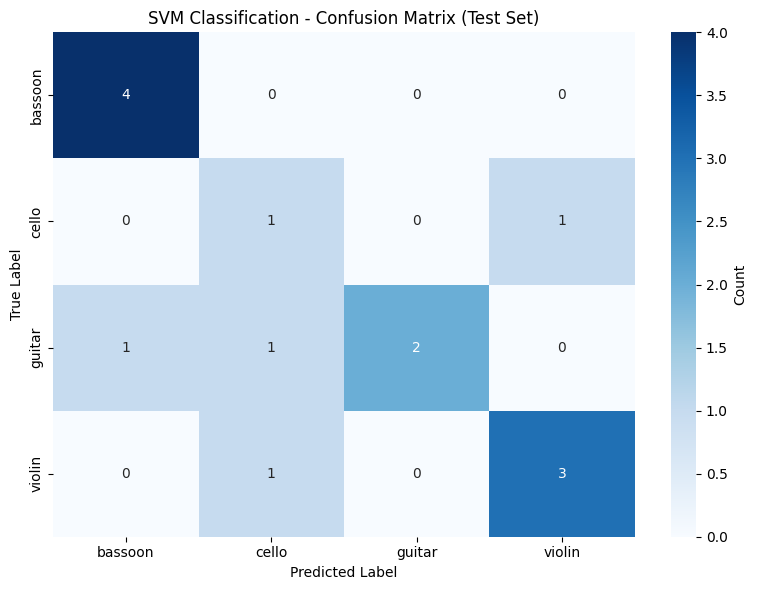


✓ Model evaluation completed!


In [12]:
# Evaluate SVM model on test set

# Make predictions
y_pred = svm_model.predict(X_test_scaled)
y_pred_proba = svm_model.predict_proba(X_test_scaled)

# Compute metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("=" * 60)
print("MODEL EVALUATION (Test Set)")
print("=" * 60)
print(f"\nOverall Performance:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall:    {recall:.4f}")
print(f"  F1-Score:  {f1:.4f}")

# Per-class metrics
print(f"\nPer-Class Metrics:")
print(classification_report(y_test, y_pred, digits=4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(f"\nConfusion Matrix:")
print(cm)

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=sorted(set(full_labels)),
            yticklabels=sorted(set(full_labels)), ax=ax, cbar_kws={'label': 'Count'})
ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.set_title('SVM Classification - Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

print("\n✓ Model evaluation completed!")

### Reading the evaluation results

#### Accuracy, Precision, Recall, F1

| Metric | Formula | What it tells you |
|--------|---------|-------------------|
| **Accuracy** | correct / total | Overall fraction of correct predictions |
| **Precision** | TP / (TP + FP) | Of all sounds predicted as class X, how many really were X? |
| **Recall** | TP / (TP + FN) | Of all sounds that were class X, how many did the model find? |
| **F1-score** | 2 × P × R / (P + R) | Harmonic mean of precision and recall — balances both |

All metrics are reported **weighted** (averaged across classes, weighted by the number of true samples per class) to handle any class imbalance.

#### Confusion matrix

Rows = true labels, columns = predicted labels.  
The diagonal shows **correct** predictions; off-diagonal cells show **confusions** between classes.

For example, a value of 2 at row *violin*, column *bassoon* means the model mistakenly labelled 2 violin sounds as bassoon.

> A perfect classifier would have non-zero values **only on the diagonal**.

#### Out-of-distribution query

After evaluating on the held-out test set, we run the same model on a **flute** sound — an instrument that was never in the training set. The model is forced to assign it to one of the three training classes. The output confidence scores tell us *how sure* the model is, and which training class it considers the closest match acoustically.


In [13]:
# ── Stage 4a: Predict the query sound (flute) ──────────────────────────────
# Load the flute descriptor from svm_query_sound/flute/, standardize it with
# the TRAINING-set statistics, and predict which training class the SVM assigns.
# Flute was never used during training — this is a true out-of-distribution query.

query_class_name = 'flute'
query_dir = Path('svm_query_sound') / query_class_name
query_json_files = sorted(query_dir.rglob('*.json'))

if not query_json_files:
    raise FileNotFoundError(
        f'No descriptor file found in {query_dir}. Run the query download cell first.'
    )

query_json_path  = query_json_files[0]
query_sound_id   = query_json_path.parent.name
query_true_label = query_class_name  # ground truth: it IS a flute

with open(query_json_path, 'r', encoding='utf-8') as _f:
    query_ftr_dict = json.load(_f)

# Convert to the same feature vector layout used during training,
# then apply the training-set mean/std normalisation.
query_raw      = convFtrDict2List(query_ftr_dict)[:len(selected_descriptors)]
query_features = ((query_raw - train_mean.ravel()) / train_std.ravel()).reshape(1, -1)

query_pred_label = svm_model.predict(query_features)[0]
query_pred_proba = svm_model.predict_proba(query_features)[0]

print('=' * 60)
print('QUERY SOUND PREDICTION')
print('  (flute — NOT a training class)')
print('=' * 60)
print(f'\nQuery Sound ID : {query_sound_id}')
print(f'True Label     : {query_true_label}  ← not in training set!')
print(f'Predicted Label: {query_pred_label}')
print()
print('Prediction Confidence:')
unique_classes = sorted(set(full_labels))
for i, cls in enumerate(unique_classes):
    confidence = query_pred_proba[i] * 100
    marker = '→' if cls == query_pred_label else ' '
    print(f'  {marker} {cls:12s}: {confidence:6.2f}%')
print(f'\nMax Confidence : {max(query_pred_proba)*100:.2f}%')
print(
    f"\nNote: flute is not a training class — the SVM assigns it to '{query_pred_label}', "
    f"the most similar training class by feature similarity."
)

QUERY SOUND PREDICTION
  (flute — NOT a training class)

Query Sound ID : 373360
True Label     : flute  ← not in training set!
Predicted Label: violin

Prediction Confidence:
    bassoon     :  29.32%
    cello       :  13.26%
    guitar      :  25.22%
  → violin      :  32.20%

Max Confidence : 32.20%

Note: flute is not a training class — the SVM assigns it to 'violin', the most similar training class by feature similarity.


In [14]:
# Save model and results for future use
results_dir = Path('svm_results')
results_dir.mkdir(exist_ok=True)

# Save the trained model
model_path = results_dir / 'svm_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(svm_model, f)
print(f"✓ Model saved to: {model_path}")

# Save standardization parameters
scaling_params = {
    'mean': train_mean,
    'std': train_std,
    'classes': sorted(set(full_labels)),
    'descriptors': selected_descriptors,
    'feature_mapping': descriptorMapping
}
scaling_path = results_dir / 'scaling_params.pkl'
with open(scaling_path, 'wb') as f:
    pickle.dump(scaling_params, f)
print(f"✓ Scaling parameters saved to: {scaling_path}")

# Save results summary
results_summary = {
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1_score': f1,
    'train_samples': len(X_train),
    'test_samples': len(X_test),
    'n_features': X_train.shape[1],
    'n_classes': len(set(full_labels)),
    'confusion_matrix': cm.tolist()
}
summary_path = results_dir / 'results_summary.pkl'
with open(summary_path, 'wb') as f:
    pickle.dump(results_summary, f)
print(f"✓ Results summary saved to: {summary_path}")

print("\n" + "=" * 60)
print("TRAINING PIPELINE COMPLETED")
print("=" * 60)
print(f"\nFinal Results:")
print(f"  Accuracy:  {accuracy:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"  Test Set Size: {len(X_test)} samples")
print(f"\nSaved Files:")
print(f"  - {model_path} (trained SVM model)")
print(f"  - {scaling_path} (normalization parameters)")
print(f"  - {summary_path} (evaluation metrics)")

✓ Model saved to: svm_results\svm_model.pkl
✓ Scaling parameters saved to: svm_results\scaling_params.pkl
✓ Results summary saved to: svm_results\results_summary.pkl

TRAINING PIPELINE COMPLETED

Final Results:
  Accuracy:  0.7143
  F1-Score:  0.7159
  Test Set Size: 14 samples

Saved Files:
  - svm_results\svm_model.pkl (trained SVM model)
  - svm_results\scaling_params.pkl (normalization parameters)
  - svm_results\results_summary.pkl (evaluation metrics)


## Stage 4: Visualization

### PCA — projecting 14 dimensions down to 2

Our feature vectors live in a 14-dimensional space that we cannot directly plot. **Principal Component Analysis (PCA)** finds the two directions in that space that capture the most variance in the data (the first and second *principal components*, PC1 and PC2) and projects every point onto those axes.

- **Each dot** is one training or test sound, coloured by its true instrument class.
- **Square markers** (⬛) are **test set** sounds — held out during training.
- **Circled markers** are **support vectors** — the training points closest to the decision boundary; they are the most informative samples for the SVM.
- **Gold star (★)** is the **flute query** — it sits somewhere in the 2D space relative to the training classes, and its position hints at why the SVM assigned it to a particular class.
- The **% variance explained** on each axis (shown in the axis labels) tells you how much information is preserved by that projection. Two components rarely capture 100%, so points that look close together in 2D might be further apart in the original 14D space.

### Interactive plot

The **Plotly** chart lets you **click any point** to play the corresponding audio preview. Hover to see the sound ID and predicted label. Use the toolbar to zoom and pan.


In [15]:
# Build combined dataset for visualization and save core results bundle
# This also writes svm_core_results.pkl so the standalone visualization notebook works.

combined_scaled_features = np.vstack([X_train_scaled, X_test_scaled])
combined_labels = np.concatenate([y_train, y_test])
combined_sound_ids = list(train_ids) + list(test_ids)
test_mask = np.concatenate([
    np.zeros(len(y_train), dtype=bool),
    np.ones(len(y_test), dtype=bool),
])
# svm_model.support_ are indices into X_train, which is the first block of combined_scaled_features
support_indices = svm_model.support_

scaled_query = query_features.ravel()

core_results = {
    'combined_scaled_features': combined_scaled_features,
    'combined_labels': combined_labels.tolist(),
    'combined_sound_ids': combined_sound_ids,
    'test_mask': test_mask.tolist(),
    'support_indices': support_indices,
    'scaled_query_features': scaled_query,
    'query_label': str(query_true_label),
    'predicted_label': str(query_pred_label),
    'predicted_probability': float(max(query_pred_proba)),
}
core_path = results_dir / 'svm_core_results.pkl'
with open(core_path, 'wb') as file_obj:
    pickle.dump(core_results, file_obj)
print(f'✓ Core results saved to: {core_path}')
print(f'  Combined samples: {len(combined_labels)} ({test_mask.sum()} test, {(~test_mask).sum()} train)')
print(f'  Support vectors: {len(support_indices)}')
print(f'  Query: {query_true_label} → predicted {query_pred_label} ({max(query_pred_proba)*100:.1f}%)')


def project_to_2d_pca(data: np.ndarray):
    if data.ndim != 2:
        raise ValueError('PCA input data must be 2D')
    centered = data - np.mean(data, axis=0, keepdims=True)
    _, singular_values, vt = np.linalg.svd(centered, full_matrices=False)
    components = vt[:2]
    projected = centered @ components.T
    variances = (singular_values ** 2) / max(data.shape[0] - 1, 1)
    total_variance = np.sum(variances)
    explained = np.zeros(2) if total_variance == 0 else variances[:2] / total_variance
    if explained.shape[0] < 2:
        explained = np.pad(explained, (0, 2 - explained.shape[0]))
    return projected, explained

✓ Core results saved to: svm_results\svm_core_results.pkl
  Combined samples: 70 (14 test, 56 train)
  Support vectors: 42
  Query: flute → predicted violin (32.2%)


Interactive backend unavailable (module://matplotlib_inline.backend_inline). Using static plot + Plotly fallback.
  Backend error: 'widget' is not a recognised GUI loop or backend name


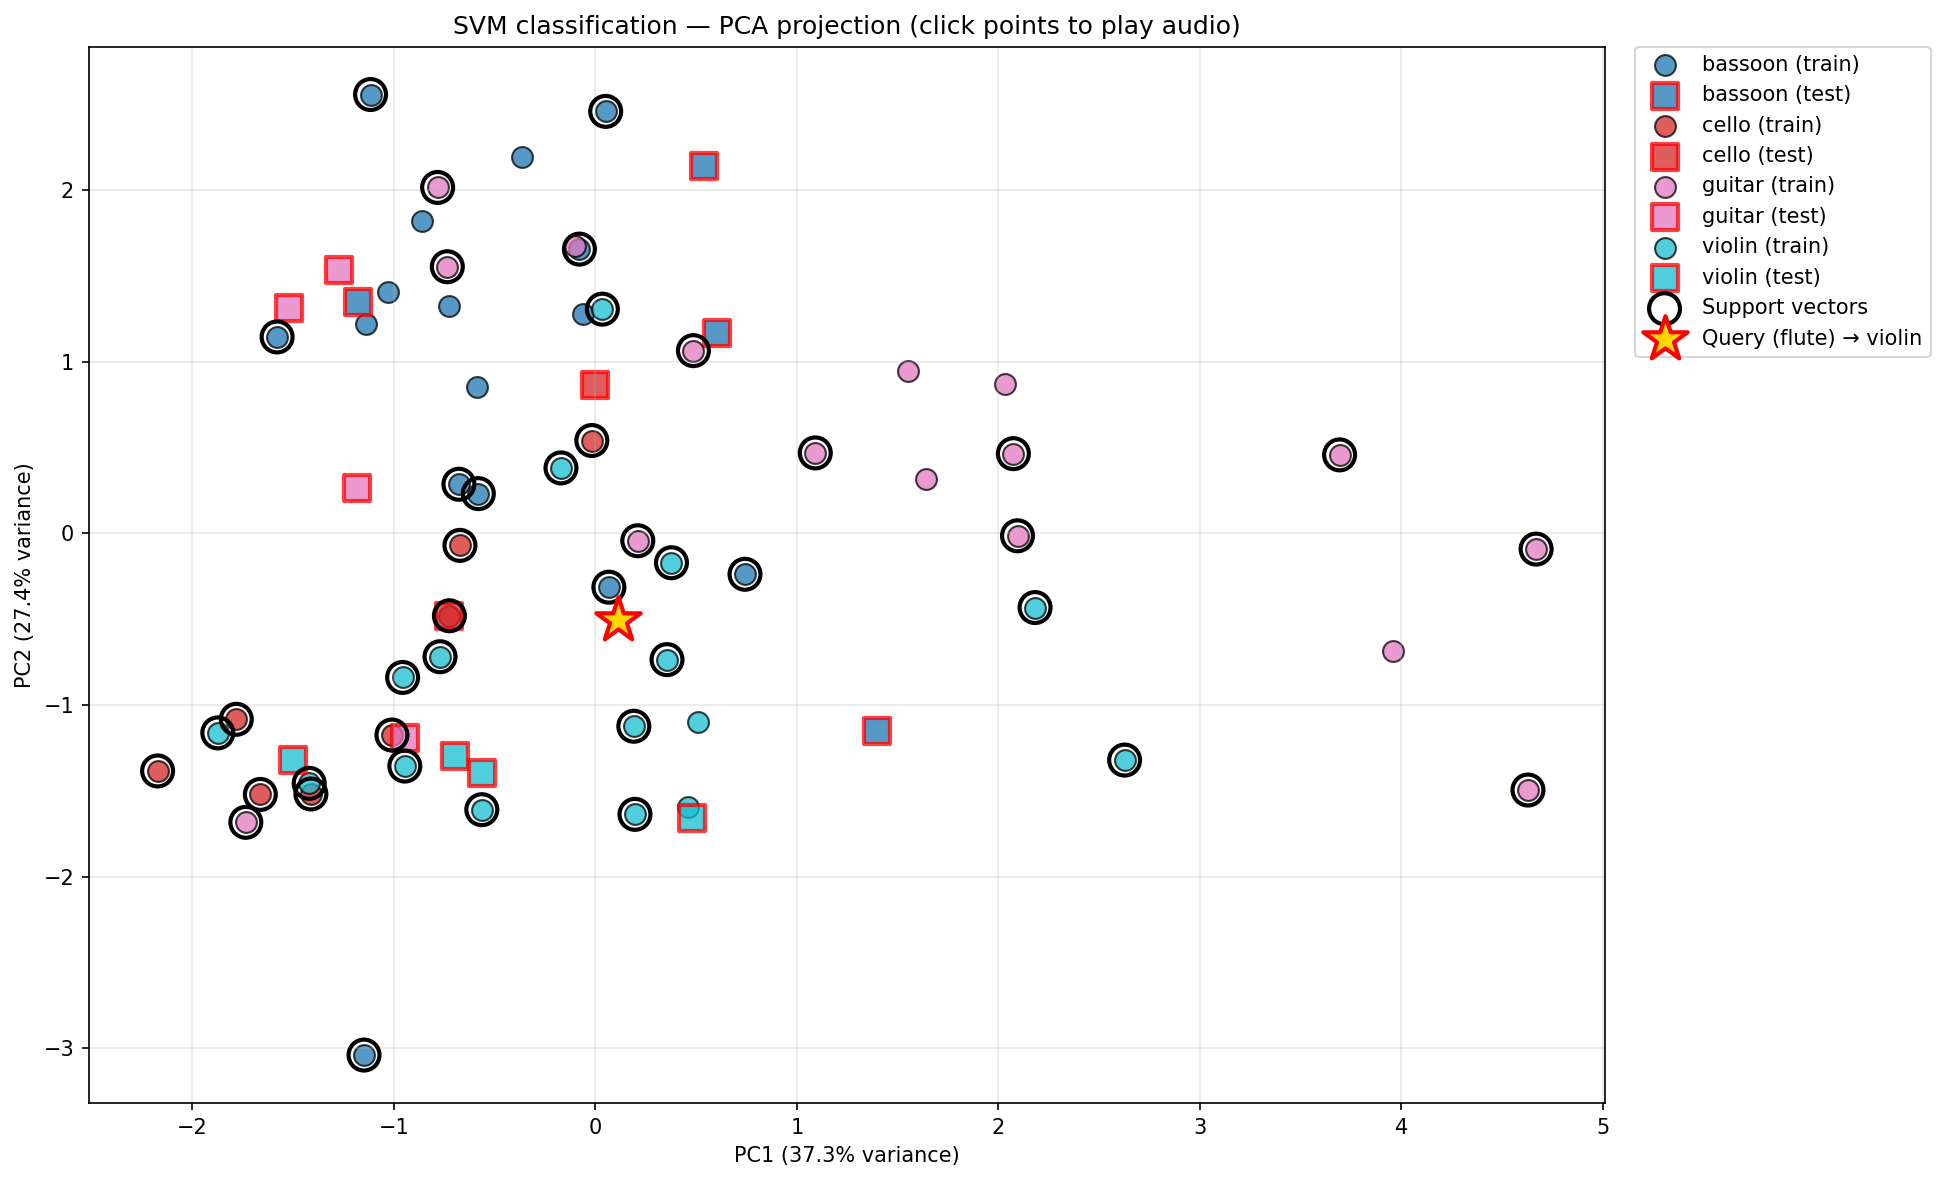

Static plot: svm_results\svm_visualization_pca.png
Plotly unavailable (No module named 'plotly'). Use play_point(index) for audio playback.


In [16]:
import matplotlib

try:
    matplotlib.use('module://ipympl.backend_nbagg')
except Exception:
    pass

ip = get_ipython()
backend_error = None
if ip is not None:
    try:
        ip.run_line_magic('matplotlib', 'widget')
        import ipympl  # noqa: F401
        plt.switch_backend('module://ipympl.backend_nbagg')
    except Exception as error:
        backend_error = error

current_backend = matplotlib.get_backend().lower()
interactive_backend_enabled = (
    any(name in current_backend for name in ('widget', 'nbagg', 'notebook', 'qt', 'tk', 'wx', 'macosx'))
    and 'inline' not in current_backend
)
if not interactive_backend_enabled:
    print(f'Interactive backend unavailable ({current_backend}). Using static plot + Plotly fallback.')
    if backend_error is not None:
        print(f'  Backend error: {backend_error}')


def _collect_audio_file_map(base_dir) -> dict:
    base_path = Path(base_dir)
    audio_map = {}
    if not base_path.exists():
        return audio_map
    for class_dir in sorted(p for p in base_path.iterdir() if p.is_dir()):
        for sound_dir in sorted(p for p in class_dir.iterdir() if p.is_dir()):
            for pattern in ('*.mp3', '*.ogg', '*.wav'):
                matches = sorted(sound_dir.glob(pattern))
                if matches:
                    audio_map[(class_dir.name, sound_dir.name)] = matches[0]
                    break
    return audio_map


def _find_query_audio_file(query_class_name) -> Path | None:
    query_dir = Path('svm_query_sound') / query_class_name
    if not query_dir.exists():
        return None
    for pattern in ('*.mp3', '*.ogg', '*.wav'):
        matches = sorted(query_dir.rglob(pattern))
        if matches:
            return matches[0]
    return None


audio_map = _collect_audio_file_map('descSounds')
query_audio_file = _find_query_audio_file(str(query_true_label))

query_point = scaled_query.reshape(1, -1)
all_points = np.vstack((combined_scaled_features, query_point))
projected, explained = project_to_2d_pca(all_points)
projected_train = projected[:-1]
projected_query = projected[-1]

fig, ax = plt.subplots(figsize=(16, 8))
unique_labels = sorted(np.unique(combined_labels))
colors = plt.cm.tab10(np.linspace(0, 1, max(len(unique_labels), 1)))
color_map = {label: colors[i % len(colors)] for i, label in enumerate(unique_labels)}

point_to_indices: dict = {}

for class_name in unique_labels:
    idx = np.where(combined_labels == class_name)[0]
    train_idx = idx[~test_mask[idx]]
    test_idx  = idx[test_mask[idx]]

    if len(train_idx) > 0:
        scatter_train = ax.scatter(
            projected_train[train_idx, 0], projected_train[train_idx, 1],
            c=[color_map[class_name]], s=100, alpha=0.75,
            edgecolors='black', linewidth=1,
            picker=True, pickradius=8,
            label=class_name if len(test_idx) == 0 else f'{class_name} (train)',
        )
        point_to_indices[scatter_train] = train_idx

    if len(test_idx) > 0:
        scatter_test = ax.scatter(
            projected_train[test_idx, 0], projected_train[test_idx, 1],
            c=[color_map[class_name]], s=150, alpha=0.75,
            edgecolors='red', linewidth=2, marker='s',
            picker=True, pickradius=8,
            label=f'{class_name} (test)',
        )
        point_to_indices[scatter_test] = test_idx

if len(support_indices) > 0:
    ax.scatter(
        projected_train[support_indices, 0], projected_train[support_indices, 1],
        s=220, facecolors='none', edgecolors='black', linewidth=2,
        label='Support vectors', zorder=4,
    )

query_artist = ax.scatter(
    projected_query[0], projected_query[1],
    c='gold', marker='*', s=500,
    edgecolors='red', linewidth=2,
    picker=True, pickradius=10,
    label=f'Query ({query_true_label}) → {query_pred_label}',
    zorder=5,
)
point_to_indices[query_artist] = np.array([-1])

ax.set_xlabel(f'PC1 ({explained[0] * 100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({explained[1] * 100:.1f}% variance)')
ax.set_title('SVM classification — PCA projection (click points to play audio)')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
ax.grid(True, alpha=0.3)

annot = ax.annotate(
    '', xy=(0, 0), xytext=(20, 20), textcoords='offset points',
    bbox=dict(boxstyle='round', fc='yellow', alpha=0.9),
    arrowprops=dict(arrowstyle='->'),
)
annot.set_visible(False)

playback_process = None


def play_file(audio_file):
    global playback_process
    if audio_file is None:
        print('No audio file for this point.')
        return
    try:
        if playback_process is not None and playback_process.poll() is None:
            playback_process.terminate()
        if platform.system() == 'Darwin':
            playback_process = subprocess.Popen(['afplay', str(audio_file)])
        elif platform.system() == 'Linux':
            playback_process = subprocess.Popen(['aplay', str(audio_file)])
        elif platform.system() == 'Windows':
            playback_process = subprocess.Popen(['start', str(audio_file)], shell=True)
        else:
            print(f'Unsupported OS: {platform.system()}')
            return
        print(f'Playing: {audio_file.name}')
    except Exception as error:
        print(f'Playback error: {error}')


def _audio_for_index(index: int):
    if index == -1:
        return query_audio_file
    return audio_map.get((str(combined_labels[index]), combined_sound_ids[index]))


def show_training_info(index: int):
    play_file(_audio_for_index(index))
    annot.xy = (projected_train[index, 0], projected_train[index, 1])
    annot.set_text('\n'.join([
        f'Sound ID: {combined_sound_ids[index]}',
        f'Class: {combined_labels[index]}',
        f'Set: {"test" if test_mask[index] else "train"}',
        f'Support vector: {"yes" if index in support_indices else "no"}',
    ]))
    annot.set_visible(True)
    fig.canvas.draw_idle()


def show_query_info():
    play_file(_audio_for_index(-1))
    annot.xy = (projected_query[0], projected_query[1])
    annot.set_text('\n'.join([
        'Sound: query (flute)',
        f'Predicted class: {query_pred_label}',
        f'Confidence: {max(query_pred_proba) * 100:.1f}%',
    ]))
    annot.set_visible(True)
    fig.canvas.draw_idle()


def show_info(meta_index: int):
    if meta_index == -1:
        show_query_info()
    else:
        show_training_info(meta_index)


def play_point(index: int):
    if index < -1 or index >= len(combined_labels):
        raise ValueError(f'index must be between -1 and {len(combined_labels) - 1}')
    show_info(int(index))


def on_pick(event):
    if event.artist not in point_to_indices or len(event.ind) == 0:
        return
    show_info(int(point_to_indices[event.artist][event.ind[0]]))


fallback_points = np.vstack((projected_train, projected_query.reshape(1, -1)))
fallback_meta   = np.append(np.arange(len(combined_labels)), -1)


def on_click(event):
    if event.inaxes != ax or event.xdata is None:
        return
    distances = np.hypot(fallback_points[:, 0] - event.xdata, fallback_points[:, 1] - event.ydata)
    show_info(int(fallback_meta[int(np.argmin(distances))]))


fig.canvas.mpl_connect('pick_event', on_pick)
fig.canvas.mpl_connect('button_press_event', on_click)
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.close(fig)

static_plot_path = Path('svm_results') / 'svm_visualization_pca.png'
fig.savefig(static_plot_path, dpi=150, bbox_inches='tight')

if not interactive_backend_enabled:
    from IPython.display import Image, display
    display(Image(filename=str(static_plot_path)))
print(f'Static plot: {static_plot_path}')

# Interactive Plotly scatter — click any marker to play the corresponding audio file
try:
    import plotly.graph_objects as go
    import ipywidgets as widgets
    from IPython.display import display

    fig_plotly = go.FigureWidget()

    for class_name in unique_labels:
        idx       = np.where(combined_labels == class_name)[0]
        train_idx = idx[~test_mask[idx]]
        test_idx  = idx[test_mask[idx]]
        r, g, b   = (int(color_map[class_name][c] * 255) for c in range(3))

        if len(train_idx) > 0:
            fig_plotly.add_scatter(
                x=projected_train[train_idx, 0], y=projected_train[train_idx, 1],
                mode='markers',
                marker=dict(size=11, color=f'rgba({r},{g},{b},0.85)', line=dict(width=1, color='black')),
                name=class_name if len(test_idx) == 0 else f'{class_name} (train)',
                customdata=train_idx.tolist(),
            )
        if len(test_idx) > 0:
            fig_plotly.add_scatter(
                x=projected_train[test_idx, 0], y=projected_train[test_idx, 1],
                mode='markers',
                marker=dict(size=14, symbol='square', color=f'rgba({r},{g},{b},0.9)', line=dict(width=2, color='red')),
                name=f'{class_name} (test)',
                customdata=test_idx.tolist(),
            )

    fig_plotly.add_scatter(
        x=[projected_query[0]], y=[projected_query[1]],
        mode='markers',
        marker=dict(size=22, symbol='star', color='gold', line=dict(width=2, color='red')),
        name=f'Query ({query_true_label}) → {query_pred_label}',
        customdata=[-1],
    )

    fig_plotly.update_layout(
        title=f'SVM classification — PCA projection  |  query: {query_true_label} → {query_pred_label} ({max(query_pred_proba)*100:.1f}%)',
        xaxis_title=f'PC1 ({explained[0] * 100:.1f}% variance)',
        yaxis_title=f'PC2 ({explained[1] * 100:.1f}% variance)',
        template='simple_white',
        width=1200, height=560,
        showlegend=True,
        legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='left', x=0),
        margin=dict(l=40, r=40, t=90, b=40),
    )

    playback_out = widgets.Output()

    def _on_plotly_click(trace, points, _state):
        if not points.point_inds:
            return
        with playback_out:
            playback_out.clear_output(wait=True)
            play_point(int(trace.customdata[points.point_inds[0]]))

    for trace in fig_plotly.data:
        trace.on_click(_on_plotly_click)

    display(widgets.VBox([fig_plotly, playback_out]))

except Exception as error:
    print(f'Plotly unavailable ({error}). Use play_point(index) for audio playback.')